# 작업 1.2: 양자 연산 적용 (파트 4) (Task 1.2: Apply Quantum Operations (Part 4))
## 목표 2: QuantumCircuit 객체 (Objective 2: The QuantumCircuit Object)

**개요:**
이 노트북은 특정 게이트보다는 `QuantumCircuit` 클래스 자체를 조작하는 데 중점을 둡니다.
*   **회로 구성 (Circuit Construction):** 초기화, 구성(Composition) 및 분해.
*   **제어 흐름 (Control Flow):** If/Else, For 루프 및 Switch 문.
*   **회로 메트릭 (Circuit Metrics):** 깊이(Depth), 너비(Width) 및 타이밍(Timing).

In [1]:

import warnings
# Filter the specific warning from Qiskit about Cregbundle
warnings.filterwarnings('ignore', message='.*Cregbundle set to False.*', category=RuntimeWarning)
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit import Qubit, Clbit, BoxOp
from qiskit.visualization import plot_histogram, plot_state_qsphere, plot_state_city
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator
from qiskit.transpiler import generate_preset_pass_manager
from qiskit.circuit.library import XGate
import qiskit.circuit.library as library


# Try to import GenericBackendV2, handling different Qiskit versions
try:
    from qiskit.providers.fake_provider import GenericBackendV2
except ImportError:
    try:
        from qiskit_ibm_runtime.fake_provider import GenericBackendV2
    except ImportError:
        GenericBackendV2 = None
        print("Warning: GenericBackendV2 not found. Transpilation examples might skip.")


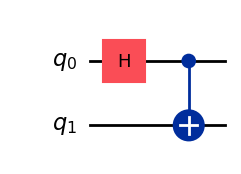

In [ ]:
from qiskit import QuantumCircuit

# Create a new circuit with two qubits

qreg = QuantumRegister(2, "qreg")
creg = QuantumRegister(2, "creg")

qc = QuantumCircuit(2)
 
# Add a Hadamard gate to qubit 0
qc.h(0)
 
# Perform a controlled-X gate on qubit 1, controlled by qubit 0
qc.cx(0, 1)
 
# Return a text drawing of the circuit.
qc.draw('mpl')

### 핵심 속성: `data` (Core Attribute: `data`)

`data` 속성은 회로를 구성하는 명령(instruction) 목록에 직접 액세스할 수 있게 해줍니다. 목록의 각 항목은 연산과 그것이 적용되는 큐비트/고전 비트를 포함하는 `CircuitInstruction` 객체입니다.

In [ ]:
print(qc.data)

[CircuitInstruction(operation=Instruction(name='h', num_qubits=1, num_clbits=0, params=[]), qubits=(<Qubit register=(2, "q"), index=0>,), clbits=()), CircuitInstruction(operation=Instruction(name='cx', num_qubits=2, num_clbits=0, params=[]), qubits=(<Qubit register=(2, "q"), index=0>, <Qubit register=(2, "q"), index=1>), clbits=())]


In [18]:
print(qc.num_qubits)
print(qc.num_clbits)

2
0


### 글로벌 위상 (Global Phase)

`global_phase` 속성은 라디안 단위로 회로의 글로벌 위상을 추적합니다. 글로벌 위상은 측정 확률에는 영향을 미치지 않지만, 회로를 제어하거나 다른 회로와 결합할 때 매우 중요합니다.

In [19]:
print(qc.global_phase)

0.0


### 레지스터 (Registers)

회로와 연결된 양자 레지스터(`qregs`) 및 고전 레지스터(`cregs`)에 액세스할 수 있습니다. 이는 회로의 구조를 검사하는 데 유용합니다.

In [5]:
print(qc.qregs)
print(qc.cregs)

[QuantumRegister(2, 'q')]
[]


### 레이아웃 (Layout)

`layout` 속성(일반적으로 트랜스파일(transpilation) 후에 채워짐)은 회로의 가상 큐비트가 장치의 물리적 큐비트에 어떻게 매핑되는지 보여줍니다.

[(Instruction(name='cx', num_qubits=2, num_clbits=0, params=[]), (0, 1)), (Instruction(name='cx', num_qubits=2, num_clbits=0, params=[]), (1, 0)), (Instruction(name='cx', num_qubits=2, num_clbits=0, params=[]), (0, 2)), (Instruction(name='cx', num_qubits=2, num_clbits=0, params=[]), (2, 0)), (Instruction(name='cx', num_qubits=2, num_clbits=0, params=[]), (1, 2)), (Instruction(name='cx', num_qubits=2, num_clbits=0, params=[]), (2, 1)), (Instruction(name='id', num_qubits=1, num_clbits=0, params=[]), (0,)), (Instruction(name='id', num_qubits=1, num_clbits=0, params=[]), (1,)), (Instruction(name='id', num_qubits=1, num_clbits=0, params=[]), (2,)), (Instruction(name='rz', num_qubits=1, num_clbits=0, params=[Parameter(λ)]), (0,)), (Instruction(name='rz', num_qubits=1, num_clbits=0, params=[Parameter(λ)]), (1,)), (Instruction(name='rz', num_qubits=1, num_clbits=0, params=[Parameter(λ)]), (2,)), (Instruction(name='sx', num_qubits=1, num_clbits=0, params=[]), (0,)), (Instruction(name='sx', num_

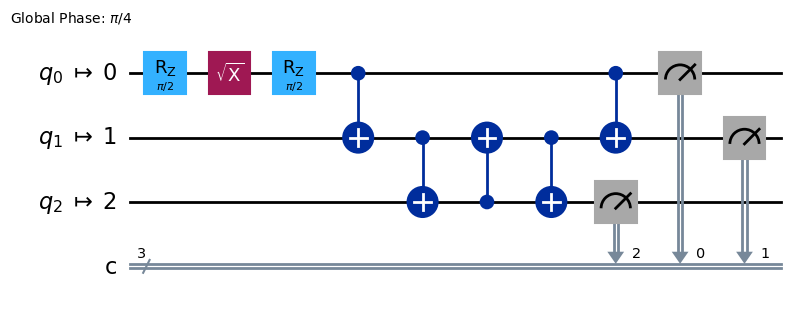

In [54]:
from qiskit import QuantumCircuit
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit.transpiler import generate_preset_pass_manager
 
# Create circuit to test transpiler on
qc = QuantumCircuit(3, 3)
qc.h(0)
qc.cx(0, 1)
qc.swap(1, 2)
qc.cx(0, 1)
 
# Add measurements to the circuit
qc.measure([0, 1, 2], [0, 1, 2])
 
# Specify the QPU to target
backend = GenericBackendV2(3)
 
# Transpile the circuit
pass_manager = generate_preset_pass_manager(
optimization_level=1, backend=backend
)
transpiled = pass_manager.run(qc)

# backend information
print(backend.instructions)


# Print the layout after transpilation
print("----------------------------------------------------------")
print(transpiled.layout.routing_permutation())
print(transpiled.layout)
transpiled.draw("mpl")

- [트랜스파일러 최적화 레벨 설정 (Set transpiler optimization level)](https://quantum.cloud.ibm.com/docs/en/guides/set-optimization)

## 회로 구성 메서드 (Circuit Construction Methods)

이 메서드들은 회로 객체를 생성하고 조작하는 데 도움을 줍니다.

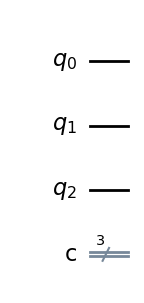

In [21]:
qc2 = qc.copy_empty_like()
qc2.draw('mpl')

### 복사 (Copy)

회로의 깊은 복사(deep copy)를 생성합니다. 이는 원본을 수정하지 않고 기존 회로를 기반으로 새 회로를 만들고 싶을 때 유용합니다.

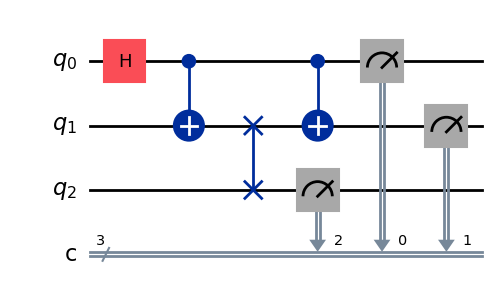

In [22]:
qc_copy = qc.copy()
# Modify copy to show independence
qc_copy.x(0)
qc.draw('mpl')


### from_qasm_str

OpenQASM 2.0 문자열 형식으로 정의된 회로를 가져옵니다.

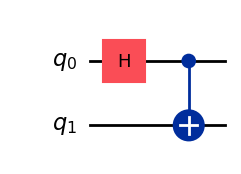

In [23]:
qasm_str = """OPENQASM 2.0;
include "qelib1.inc";
qreg q[2];
h q[0];
cx q[0],q[1];"""
qc = QuantumCircuit.from_qasm_str(qasm_str)
qc.draw('mpl')


## 데이터 객체 (Data Objects)

회로 내의 와이어(큐비트 및 고전 비트)와 변수들을 관리하는 메서드들입니다.

In [24]:
from qiskit.circuit import QuantumCircuit
 
qc = QuantumCircuit(2)
my_var = qc.add_var("my_var", False)

### add_bits

개별 양자 또는 고전 비트를 회로에 수동으로 추가합니다. 이는 와이어별로 유연한 회로를 구축하는 데 유용합니다.

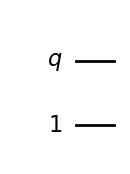

In [25]:
from qiskit.circuit import Qubit
qc = QuantumCircuit(1)
new_bit = Qubit()
qc.add_bits([new_bit])
qc.draw('mpl')


### add_register

전체 레지스터(`QuantumRegister` 또는 `ClassicalRegister`)를 회로에 추가합니다.

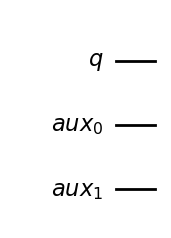

In [26]:
from qiskit import QuantumRegister
qc = QuantumCircuit(1)
qr = QuantumRegister(2, 'aux')
qc.add_register(qr)
qc.draw('mpl')


### add_input

실시간 고전 입력 변수를 추가합니다. 이는 런타임에 입력이 제공될 수 있는 동적 회로(dynamic circuit)를 위한 기능입니다.

Successfully added input variable: Var(UUID('f7d1999b-5191-4c90-9ff6-24a487ce3418'), Bool(), name='x')


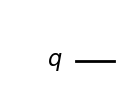

In [ ]:
from qiskit import QuantumCircuit
import qiskit
from qiskit.circuit.classical import types

qc = QuantumCircuit(1)

# Preferred usage: pass an instance from qiskit.circuit.classical.types
# Older code sometimes used a deprecated `dtype` keyword or different signatures,
# so we attempt the modern call and provide a fallback with an explanatory note.
try:
    # Add a boolean input variable named 'x' (modern API)
    x_var = qc.add_input("x", types.Bool())
    print("Successfully added input variable:", x_var)
except TypeError:
    try:
        # Some Qiskit versions accept the type class itself as a fallback
        x_var = qc.add_input("x", types.Bool)
        print("Successfully added input variable (fallback):", x_var)
    except Exception as e:
        print("Error adding input variable (see note above):", e)

# Note: if you previously saw errors, that was likely due to a deprecated/changed
# add_input signature in older Qiskit versions. The approach above attempts
# the modern call first and falls back if needed

### 비트 작업 (Working with Bits)

Qiskit은 정수 인덱스와 비트 인스턴스 간을 원활하게 변환할 수 있는 도구를 제공합니다.

In [58]:
from qiskit.circuit import QuantumCircuit, Qubit
 
qc = QuantumCircuit(3, 3)
qc.h(0)
qc.cx(0, 1)
qc.cx(1, 2)
qc.measure([0, 1, 2], [0, 1, 2])
 
# The `.qubits` and `.clbits` fields are not integers.
assert isinstance(qc.data[0].qubits[0], Qubit)
# ... but we can use `find_bit` to retrieve them.
assert qc.find_bit(qc.data[0].qubits[0]).index == 0
 
simple = [
    (
        instruction.operation.name,
        [qc.find_bit(bit).index for bit in instruction.qubits],
        [qc.find_bit(bit).index for bit in instruction.clbits],
    )
    for instruction in qc.data
]

## 연산 추가 (Adding Operations)

명령을 추가하고 회로를 결합하는 메서드들입니다.
여기에는 회로 구조를 변경하는 연산들이 포함됩니다. 예를 들어, `tensor`는 시스템을 더 큰 힐베르트 공간(Hilbert space)으로 합성합니다. 즉, 이는 각각의 피연산자 시스템의 상태 공간의 텐서곱(tensor product)인 더 큰 시스템을 생성하는 것과 동일합니다.

In [59]:
qc2.x(0)
qc.tensor(qc2).draw()

┌───┐┌───┐┌───┐         
q_0: ┤ X ├┤ X ├┤ X ├─────────
     └───┘└───┘└───┘         
q_1: ────────────────────────
                             
q_2: ────────────────────────
     ┌───┐          ┌─┐      
q_3: ┤ H ├──■───────┤M├──────
     └───┘┌─┴─┐     └╥┘┌─┐   
q_4: ─────┤ X ├──■───╫─┤M├───
          └───┘┌─┴─┐ ║ └╥┘┌─┐
q_5: ──────────┤ X ├─╫──╫─┤M├
               └───┘ ║  ║ └╥┘
c: 6/════════════════╩══╩══╩═
                     3  4  5

### append

회로에 임의의 `Instruction` 객체를 추가하는 가장 기본적인 메서드입니다. 대부분의 게이트 메서드들은 내부적으로 이를 호출합니다.

- [`Instruction`](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.Instruction)

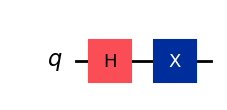

In [75]:
from qiskit.circuit.library import XGate
qc = QuantumCircuit(1)
qc.h(0)
# Append an X gate
qc.append(XGate(), [0])
qc.draw('mpl')


### compose

이 회로를 다른 회로와 결합합니다. `append`와 달리, `compose`는 다른 회로를 단일 불투명 명령(opaque instruction)으로 추가하는 대신 이 회로 내에 평탄화(flattening)하여 넣습니다.

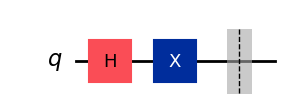

In [82]:
qc1 = QuantumCircuit(1)
qc1.h(0)
qc2 = QuantumCircuit(1)
qc2.x(0)
qc2.barrier(0)
# Compose qc2 onto qc1
qc = qc1.compose(qc2, [0])
qc.draw('mpl')


### compose vs append (Compose vs Append)

`compose()`는 두 번째 회로를 첫 번째 회로에 평탄화하여 게이트들이 인라인으로 나타나게 합니다. `append()`는 다른 회로를 단일 불투명 명령(박스형 게이트)으로 추가합니다. 시각적으로 한 케이스는 확장된 상태로 보이고 다른 케이스는 단일 박스로 보입니다. 아래 예제는 동일한 작은 회로들에 대해 `append()`를 사용하여 두 그림을 비교할 수 있도록 보여줍니다.

- [`append`](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.QuantumCircuit#qiskit.circuit.QuantumCircuit.append)
- [`compose`](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.QuantumCircuit#qiskit.circuit.QuantumCircuit.compose)

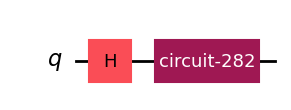

In [81]:
# Demonstrate append() so it appears as an opaque instruction
qc1 = QuantumCircuit(1)
qc1.h(0)
qc2 = QuantumCircuit(1)
qc2.x(0)
# qc2.barrier(0)
# Make a copy so we don't mutate the previous example
qc_app = qc1.copy()
# Convert qc2 into a single gate/instruction and append it
qc_app.append(qc2.to_gate(), [0])
qc_app.draw('mpl')


In [83]:
# Demonstrate append() so it appears as an opaque instruction
qc1 = QuantumCircuit(1)
qc1.h(0)
qc2 = QuantumCircuit(1)
qc2.x(0)
qc2.barrier()
# qc2.barrier(0)
# Make a copy so we don't mutate the previous example
qc_app = qc1.copy()
# Convert qc2 into a single gate/instruction and append it
qc_app.append(qc2.to_gate(), [0])
qc_app.draw('mpl')


QiskitError: 'One or more instructions cannot be converted to a gate. "barrier" is not a gate instruction'

## 표준 명령 (Standard Instructions)

이 메서드들은 표준 양자 회로 연산을 구현합니다.

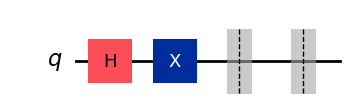

In [84]:
qc.barrier()

qc.draw('mpl')

### 지연 (delay)

큐비트에 지연(유휴 시간)을 적용합니다. 이는 스케줄링 및 노이즈 특성 분석 작업에 사용됩니다. 지연은 큐비트의 유휴/대기 시간을 나타내며, 스케줄링 일시 정지 및 결맞음 해짐(decoherence)에 대한 노출을 모델링하므로 실험의 타이밍과 노이즈를 추론할 때 유용합니다.

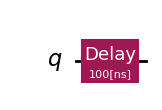

In [85]:
qc = QuantumCircuit(1)
qc.delay(100, 0, unit='ns')
qc.draw('mpl')


### 초기화 (initialize)

큐비트를 특정 상태(예: 상태 벡터로부터)로 초기화합니다. 이는 일반적으로 유니터리 연산(unitary operation)이 아니며 리셋/준비 과정을 포함합니다.

- [상태 준비 (statePreparation)](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.StatePreparation)
- [상태 준비 메서드 (prepare_state())](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.QuantumCircuit#qiskit.circuit.QuantumCircuit.prepare_state)
- [초기화 메서드 (initialize())](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.QuantumCircuit#qiskit.circuit.QuantumCircuit.initialize)

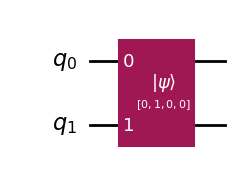

In [ ]:
qc = QuantumCircuit(2)
qc.initialize([0, 1, 0, 0], [0, 1]) # Initialize to |01>
qc.draw('mpl')


### 리셋 (reset)

회로 중간에 큐비트를 |0> 상태로 리셋합니다. 이는 비-유니터리(non-unitary) 동적 연산입니다.

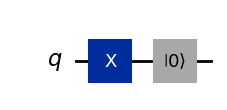

In [87]:
qc = QuantumCircuit(1)
qc.x(0)
qc.reset(0)
qc.draw('mpl')


### 저장 (store)

고전 값을 고전 비트에 저장합니다. 이는 Qiskit의 동적 회로(dynamic circuit) 기능의 일부입니다.

Successfully added a 'store' instruction to the circuit.


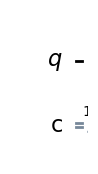


--- Environment Info ---
qiskit version: 2.1.2
Last instruction in circuit data: CircuitInstruction(operation=Instruction(name='store', num_qubits=0, num_clbits=0, params=[Var(<Clbit register=(1, "c"), index=0>, Bool()), Cast(Value(1, Uint(8)), Bool(), implicit=True)]), qubits=(), clbits=())


In [89]:
# Import the necessary components from Qiskit
import qiskit
from qiskit import QuantumCircuit
from qiskit.circuit.classical import types, expr

# --- The Correct Way to use qc.store in Modern Qiskit ---

# 1. Create a circuit with classical bits
qc = QuantumCircuit(1, 1)
target_clbit = qc.clbits[0]

# 2. Define the classical value you want to store.
# We use expr.lift() to create a classical literal from a Python value and a Qiskit type.
# For example, let's store the integer value 1 into an 8-bit unsigned integer type.
uint_value_to_store = expr.lift(1, types.Uint(8))

# 3. Use the store instruction within a try...except block for safety
try:
    qc.store(target_clbit, uint_value_to_store)
    print("Successfully added a 'store' instruction to the circuit.")
    # Draw the circuit to see the 'Store' instruction
    display(qc.draw('mpl'))
except Exception as e:
    print(f"The 'store' instruction failed: {e}")

# --- Environment Info ---
print("\n--- Environment Info ---")
# The correct way to get the version in modern Qiskit
print('qiskit version:', qiskit.__version__)

# Inspect the circuit data to confirm the instruction was added
if qc.data:
    print('Last instruction in circuit data:', qc.data[-1])
else:
    print('No instructions in the circuit.')

## 비제어 유니터리 게이트 (Uncontrolled Unitary Gates)

제어 조건이 없는 표준 단일 및 다중 큐비트 게이트입니다(예: X, H, Swap).

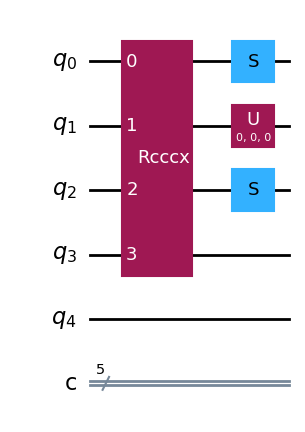

In [90]:
qc = QuantumCircuit(5,5)

qc.rcccx(0,1,2,3)
qc.s([0,2])
qc.u(0,0,0,1)

qc.draw('mpl')

## 제어 유니터리 게이트 (Controlled Unitary Gates)

제어 큐비트의 상태에 따라 활성화되는 게이트입니다(예: CX, CCX, CRZ).

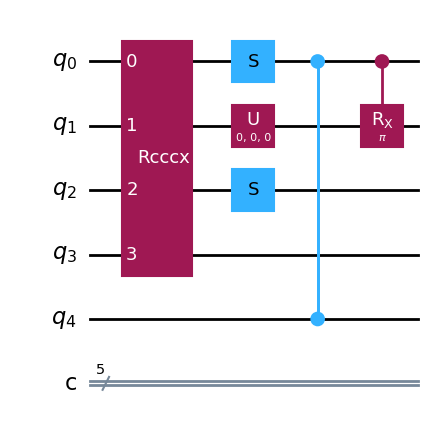

In [91]:
qc.cz(0,4)
qc.crx(np.pi,0,1)


qc.draw('mpl')

## 다중 제어 게이트 (Multiply Controlled Gates)

여러 제어 라인을 가진 게이트로, 복잡한 조건부 로직을 제공합니다.

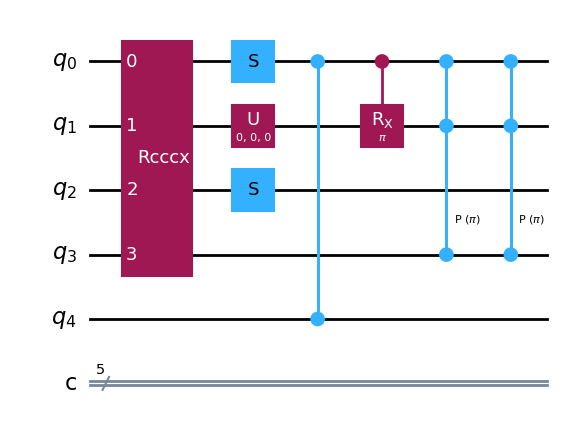

In [93]:
qc.mcp(np.pi,[0,1],3)

qc.draw('mpl')

## 제어 흐름 (Control Flow) (동적 회로 (Dynamic Circuits))

이 연산들은 회로 중간의 측정 결과에 따라 동작을 변경할 수 있는 동적 회로를 가능하게 합니다.

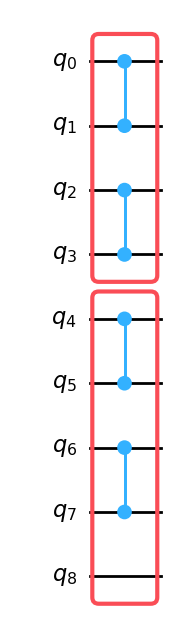

In [113]:
from qiskit.circuit import QuantumCircuit, BoxOp
 
body_0 = QuantumCircuit(4)
body_0.cz(0, 1)
body_0.cz(2, 3)
 
# Note that the qubit indices inside a body related only to the body.  The
# association with qubits in the containing circuit is made by the ``qubits``
# argument to `QuantumCircuit.box`.
body_1 = QuantumCircuit(5)
body_1.cz(0, 1)
body_1.cz(2, 3)
 
qc = QuantumCircuit(9)
qc.box(body_0, [0, 1, 2, 3], [])
qc.box(body_1, [4, 5, 6, 7, 8], [])

qc.draw("mpl")

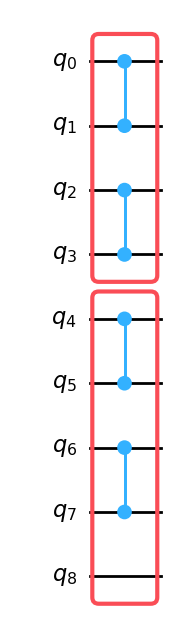

In [108]:
from qiskit.circuit import QuantumCircuit
 
 
qc = QuantumCircuit(9)
with qc.box():
    qc.cz(0, 1)
    qc.cz(2, 3)
with qc.box():
    qc.cz(4, 5)
    qc.cz(6, 7)
    qc.noop(8)

qc.draw('mpl')

In [109]:
import warnings
from qiskit import QuantumCircuit
qc = QuantumCircuit(2, 1)
 
with qc.for_loop(range(5)) as i:
    qc.x(0)
    qc.cx(0, 1)
    qc.measure(0, 0)
    with qc.if_test((0, True)):
        qc.break_loop()

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    qc.draw()

In [114]:
from qiskit.circuit import QuantumCircuit
 
qc = QuantumCircuit(3)
with qc.box():
    # This control-flow block will only use qubits 0 and 1.
    qc.cx(0, 1)
with qc.box():
    # This control-flow block will contain only the same operation as the previous
    # block, but it will also mark qubit 2 as "used" by the box.
    qc.cx(0, 1)
    qc.noop(2)

### 조건문 (if_else)

조건이 참이면 하나의 명령 블록을 실행하고, 선택적으로 거짓일 때 다른 블록을 실행합니다.

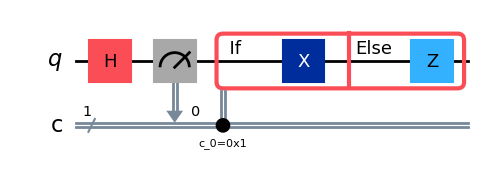

In [115]:
import warnings
# Suppress specific Qiskit warning about Cregbundle
warnings.filterwarnings('ignore', message='.*Cregbundle.*')
qc = QuantumCircuit(1, 1)
qc.h(0)
qc.measure(0, 0)
with qc.if_test((0, 1)) as else_block:
    qc.x(0)
with else_block:
    qc.z(0)
qc.draw('mpl')


### while_loop

고전적 조건이 참으로 평가되는 동안 명령 블록을 반복합니다.

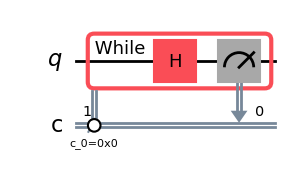

In [118]:
import warnings
# Suppress specific Qiskit warning about Cregbundle
warnings.filterwarnings('ignore', message='.*Cregbundle.*')
qc = QuantumCircuit(1, 1)
with qc.while_loop((0, 0)):
    qc.h(0)
    qc.measure(0, 0)
qc.draw('mpl')


### switch

고전적 표현식의 값에 따라 특정 명령 블록을 실행합니다 (switch-case 문과 유사).

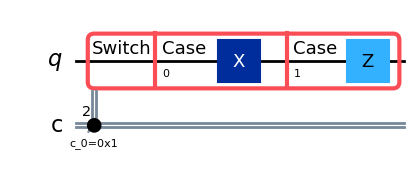

In [119]:
import warnings
# Suppress specific Qiskit warning about Cregbundle
warnings.filterwarnings('ignore', message='.*Cregbundle.*')
qc = QuantumCircuit(1, 2)
with qc.switch(0) as case:
    with case(0):
        qc.x(0)
    with case(1):
        qc.z(0)
qc.draw('mpl')


### continue_loop

현재 반복의 나머지 부분을 건너뛰고 가장 가까운 외부 루프의 다음 반복으로 점프합니다.

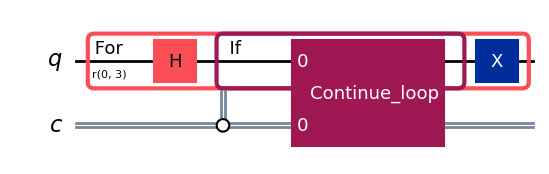

In [120]:
import warnings
# Suppress specific Qiskit warning about Cregbundle
warnings.filterwarnings('ignore', message='.*Cregbundle.*')
qc = QuantumCircuit(1, 1)
with qc.for_loop(range(3)):
    qc.h(0)
    with qc.if_test((0, 0)):
        qc.continue_loop()
    qc.x(0)
qc.draw('mpl')


## 변환기 (Converters)

재사용을 위해 회로를 단일 `Instruction` 또는 `Gate` 객체로 패키징하는 메서드들입니다.

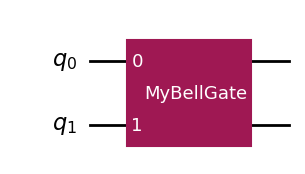

In [121]:
# Create a circuit without measurements for to_gate
qc_gate = QuantumCircuit(2)
qc_gate.h(0)
qc_gate.cx(0, 1)

# Convert to gate
my_gate = qc_gate.to_gate()
my_gate.name = "MyBellGate"

# Use the gate in a new circuit
main_qc = QuantumCircuit(2)
main_qc.append(my_gate, [0, 1])
main_qc.draw('mpl')


## 헬퍼 변이 메서드 (Helper Mutation Methods)

회로를 제자리에서(in place) 수정하여 실행 준비를 돕는 메서드들입니다.

In [122]:
qc3= QuantumCircuit(3)

qc3.h(0)
qc3.cx(0,2)
qc3.measure_active()
qc3.draw()


┌───┐      ░ ┌─┐   
   q_0: ┤ H ├──■───░─┤M├───
        └───┘  │   ░ └╥┘   
   q_1: ───────┼───░──╫────
             ┌─┴─┐ ░  ║ ┌─┐
   q_2: ─────┤ X ├─░──╫─┤M├
             └───┘ ░  ║ └╥┘
meas: 2/══════════════╩══╩═
                      0  1

In [125]:
qc3= QuantumCircuit(3)

qc3.h(0)
qc3.cx(0,2)
qc3.measure_all()
qc3.draw()


┌───┐      ░ ┌─┐      
   q_0: ┤ H ├──■───░─┤M├──────
        └───┘  │   ░ └╥┘┌─┐   
   q_1: ───────┼───░──╫─┤M├───
             ┌─┴─┐ ░  ║ └╥┘┌─┐
   q_2: ─────┤ X ├─░──╫──╫─┤M├
             └───┘ ░  ║  ║ └╥┘
meas: 3/══════════════╩══╩══╩═
                      0  1  2

In [126]:
qc3.remove_final_measurements()
qc3.draw()

┌───┐     
q_0: ┤ H ├──■──
     └───┘  │  
q_1: ───────┼──
          ┌─┴─┐
q_2: ─────┤ X ├
          └───┘

### 전체 측정 (measure_all)

모든 큐비트에 측정을 추가하며, 필요한 경우 고전 레지스터(classical register)를 확장합니다.

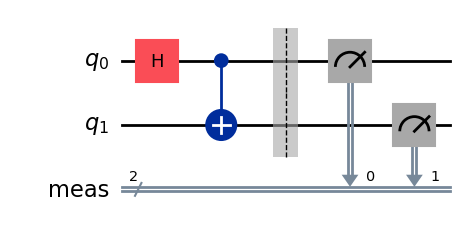

In [38]:
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
qc.measure_all()
qc.draw('mpl')


### 비우기 (clear)
회로에서 모든 명령을 제거합니다.


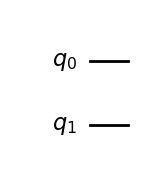

In [127]:
qc = QuantumCircuit(2)
qc.h(0)
qc.clear()
# Circuit should be empty
qc.draw('mpl')


## 회로 메트릭 및 스케줄링 (Circuit Metrics & Scheduling)

회로의 속성과 타이밍을 분석하는 도구들입니다.

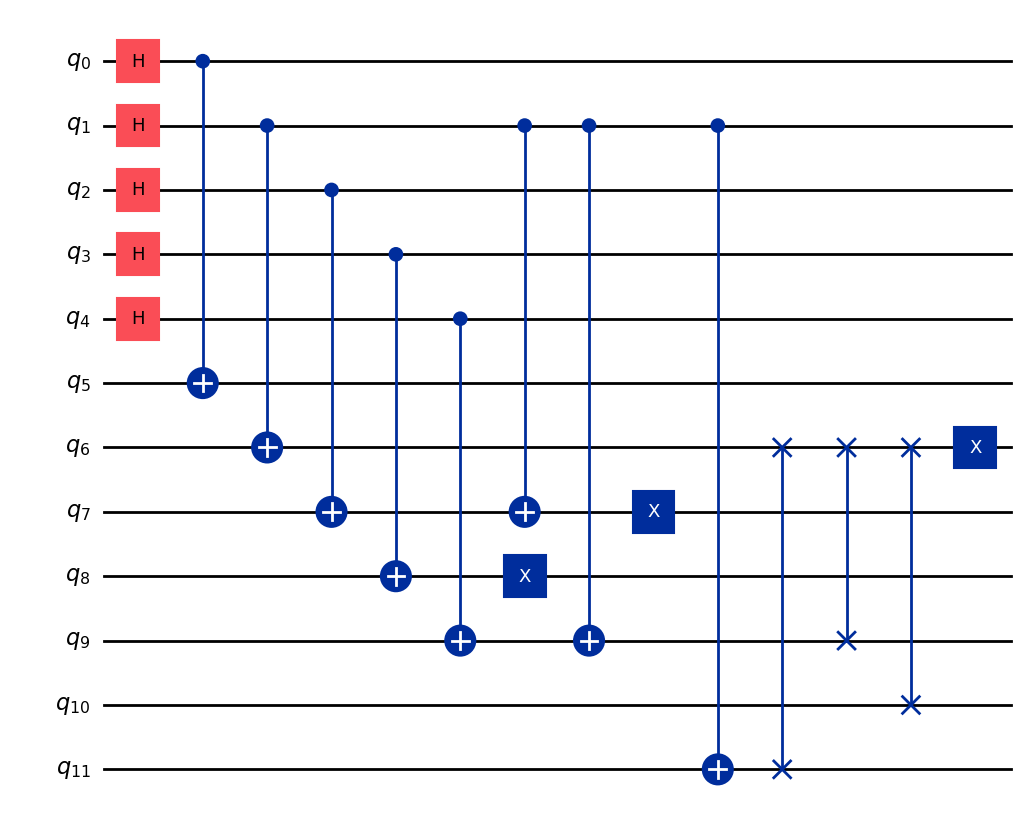

In [128]:
from qiskit import QuantumCircuit
qc = QuantumCircuit(12)
for idx in range(5):
   qc.h(idx)
   qc.cx(idx, idx+5)
 
qc.cx(1, 7)
qc.x(8)
qc.cx(1, 9)
qc.x(7)
qc.cx(1, 11)
qc.swap(6, 11)
qc.swap(6, 9)
qc.swap(6, 10)
qc.x(6)
qc.draw('mpl')

In [134]:
assert qc.width() == 12

In [130]:
assert qc.num_qubits == 12

In [131]:
print(f"Circuit depth: {qc.depth()}")

Circuit depth: 9


In [132]:
qc.count_ops()

OrderedDict([('cx', 8), ('h', 5), ('x', 3), ('swap', 3)])

스케줄링 정보 액세스 (Accessing Scheduling Information)

* 예상 소요 시간 (estimate_duration)
* 큐비트 소요 시간 (qubit_duration)
* 큐비트 시작 시간 (qubit_start_time)
* 큐비트 종료 시간 (qubit_stop_time)

### 예상 소요 시간 산출 (estimate_duration)

백엔드에서 제공하는 게이트 시간을 기반으로 회로의 총 소요 시간을 예측합니다.

In [135]:
from qiskit.providers.fake_provider import GenericBackendV2
qc = QuantumCircuit(1)
qc.delay(100, 0, unit='dt')
# Use at least 2 qubits for the fake backend so multi-qubit basis gates exist
backend = GenericBackendV2(num_qubits=2)
# Pass the backend target (timing info) to estimate_duration
print(f"Duration: {qc.estimate_duration(backend.target)}")

Duration: 2.22e-08


### 큐비트 소요 시간 (qubit_duration)

특정 큐비트에서의 연산 소요 시간을 반환합니다.

In [46]:
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit.transpiler import generate_preset_pass_manager

# Use a fake backend to simulate real hardware timing
backend = GenericBackendV2(num_qubits=2)

# Transpile and schedule the circuit
pm = generate_preset_pass_manager(target=backend.target, optimization_level=1)
qc_scheduled = pm.run(qc)

# Now we can query duration with valid timing data
print(f"Qubit 0 duration: {qc_scheduled.qubit_duration(0)}")


Qubit 0 duration: 0


Demo qubit 0 duration: 3133
Demo qubit 0 start time: 0
Demo qubit 0 stop time: 3133


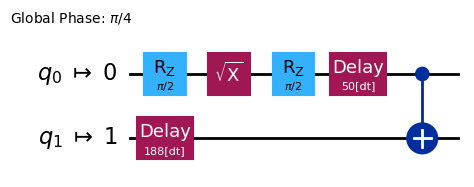

In [47]:
# More illustrative scheduling demo: build a small circuit with gates and delays,
# then schedule it with a fake backend so qubit_duration/start/stop are non-zero.
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit.transpiler import generate_preset_pass_manager
from qiskit import QuantumCircuit

backend = GenericBackendV2(num_qubits=3)
# Use transpile with a scheduling method so start/stop times are populated
from qiskit import transpile

qc_demo = QuantumCircuit(2)
qc_demo.h(0)
qc_demo.delay(50, 0, unit='dt')
qc_demo.cx(0, 1)

# Transpile with scheduling (ALAP) to assign instruction start/stop times
qc_demo_scheduled = transpile(qc_demo, backend=backend, optimization_level=1, scheduling_method='alap')
print("Demo qubit 0 duration:", qc_demo_scheduled.qubit_duration(0))
print("Demo qubit 0 start time:", qc_demo_scheduled.qubit_start_time(0))
print("Demo qubit 0 stop time:", qc_demo_scheduled.qubit_stop_time(0))
qc_demo_scheduled.draw('mpl')


### 큐비트 시작 시간 및 종료 시간 (qubit_start_time and qubit_stop_time)

이 메서드들은 특정 큐비트에서의 연산에 대해 예약된 시작 및 종료 시간을 반환합니다.

중요한 점은, 이 메서드들은 회로가 스케줄링 방법(예: 'alap' 또는 'asap')으로 트랜스파일(transpile)된 경우에만 0이 아닌 값을 반환한다는 것입니다. 이전 섹션의 qc_scheduled 객체는 스케줄링 패스 없이 생성되었으므로 아래와 같이 타이밍 정보가 기본값인 0으로 유지됩니다. 이는 스케줄링되어 유효한 타이밍 데이터를 포함하는 qc_demo_scheduled 객체와 대조됩니다.


 scheduling_method가 지정된 경우 트랜스파일에 의해 반환된 새 객체에만 타이밍 정보가 존재하므로, qc_scheduled 객체를 쿼리하면 여전히 시작 및 종료 시간에 대해 0이 산출된다는 점에 유의하십시오.

In [48]:
# Check start and stop times for Qubit 0
print(f"Qubit 0 start time: {qc_scheduled.qubit_start_time(0)}")
print(f"Qubit 0 stop time: {qc_scheduled.qubit_stop_time(0)}")


Qubit 0 start time: 0
Qubit 0 stop time: 0


## 명령 수식어 (Instruction Modifiers)

수정된 속성(예: 제어됨 또는 반전됨)을 가진 회로의 새 버전을 반환하는 메서드들입니다.

#### **1. `control()` 메서드**

`.control()` 메서드는 기존 회로나 게이트를 가져와 하나 이상의 제어 큐비트가 있는 새 버전을 반환하는 강력한 도구입니다. 이를 통해 복잡한 연산을 수동으로 분해하지 않고도 제어된 버전을 쉽게 만들 수 있습니다.

아래 예제에서는 단일 하다마드(Hadamard) 게이트를 포함하는 간단한 1-큐비트 회로로 시작합니다. 그런 다음 `.control(1)`을 사용하여 새로운 2-큐비트 제어 하다마드(controlled-Hadamard) 게이트를 만듭니다. 출력 다이어그램에서 원래 `h` 게이트가 타겟 `q1`에 작용하는 `q0`의 제어 포인트를 가진 단일 블록으로 어떻게 표시되는지 확인하십시오.

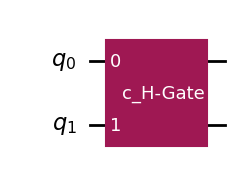

In [2]:
from qiskit import QuantumCircuit

# Create a simple circuit for a single H-gate
qc_h = QuantumCircuit(1, name='H-Gate')
qc_h.h(0)

# Add one control qubit to the H-gate circuit
# The original qubit (0) becomes the target (now on wire 1)
# The new control is on wire 0
controlled_h_gate = qc_h.control(1)

# You can now use this new gate in another circuit
main_qc = QuantumCircuit(2)
main_qc.append(controlled_h_gate, [0, 1])
main_qc.draw('mpl')


#### **2. `inverse()` 메서드**

`.inverse()` 메서드는 회로의 수학적 역행렬(켤레 전치(conjugate transpose) 또는 $U^\dagger$)을 계산합니다. 적용하면 모든 게이트가 역순으로 적용되고 각 게이트가 해당 게이트의 역변환으로 대체된 새 회로를 반환합니다.

이는 진폭 증폭(amplitude amplification)이나 상태를 해제(uncompute)하는 알고리즘과 같은 많은 알고리즘에 매우 유용합니다.

아래 예제에서 반전된 회로가 원래 순서와 반대로 `Sdg`(S-dagger) 게이트와 `H` 게이트를 어떻게 적용하는지 확인하십시오.

Original Circuit:


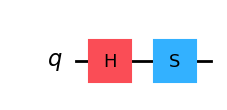


Inverted Circuit:


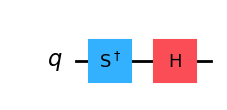

In [3]:
# Create a circuit with a non-symmetrical sequence of gates
qc = QuantumCircuit(1)
qc.h(0)
qc.s(0)

print("Original Circuit:")
display(qc.draw('mpl'))

# Now, compute the inverse
qc_inv = qc.inverse()

print("\nInverted Circuit:")
display(qc_inv.draw('mpl'))

#### **3. `power()` 메서드**

`.power()` 메서드를 사용하면 게이트 또는 회로를 특정 거듭제곱으로 올릴 수 있습니다. 이는 게이트의 유니터리 행렬 $U$를 그 자체에 *n*번 적용하는 것($U^n$)과 동일합니다.

이는 분수 거듭제곱이나 알려진 게이트 항등식을 입증하는 데 특히 유용합니다. 예를 들어, T-게이트를 두 번 적용하는 것이 단일 S-게이트를 적용하는 것과 동일하다는 것을 알고 있습니다($T^2 = S$). 아래 코드는 T-게이트를 생성하고 이를 2제곱으로 올리며, 결과 회로 다이어그램은 S-게이트를 올바르게 보여줍니다.

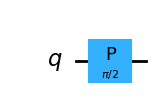

In [ ]:
from qiskit.circuit.library import TGate

# Create a circuit with a single T-gate
qc = QuantumCircuit(1)
qc.append(TGate().power(2), [0])

# The output diagram will show an S-gate (Phase Gate where theta=π/2), because T^2 = S
qc.draw('mpl')

#### **4. `reverse_ops()` 메서드**

`.reverse_ops()` 메서드는 회로의 명령 순서를 반전시킵니다. 이 메서드는 **순서만 반전**시킬 뿐, (`.inverse()` 메서드와 달리) 각 게이트의 역변환을 취하지 않는다는 점에 유의하는 것이 중요합니다.

이는 상태 준비 회로를 준비하거나 특정 알고리즘 단계를 수동으로 구성하는 데 유용합니다. 효과를 보려면 원래 회로를 아래의 반전된 회로와 비교해 보십시오.


Original Circuit:


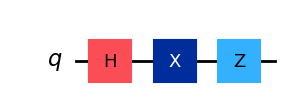


Reversed Circuit:


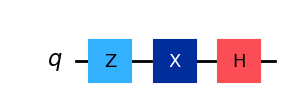

In [7]:
# Create a circuit with a clear sequence of different gates
qc = QuantumCircuit(1)
qc.h(0)
qc.x(0)
qc.z(0)

print("Original Circuit:")
display(qc.draw('mpl'))

# Now, reverse the operations
qc_rev = qc.reverse_ops()

print("\nReversed Circuit:")
display(qc_rev.draw('mpl'))

## 시각화: `reverse_bits`를 사용한 비트 순서 관리 (Visualization: Managing Bit Ordering with reverse_bits)

`.reverse_bits()` 메서드는 회로의 큐비트 순서를 반전시킵니다. 이는 엔디언(endianness)이라고도 하는 Qiskit의 비트 순서 규칙을 관리하기 위한 중요한 헬퍼 메서드입니다.

*   **Qiskit의 기본값 (Little-Endian):** 기본적으로 Qiskit은 리틀 엔디언(little-endian) 순서를 사용합니다. 이는 양자 상태를 이진 문자열로 표현할 때 인덱스 0의 큐비트(`q_0`)가 *최하위 비트*(LSB)임을 의미합니다. 예를 들어, $|101\rangle$ 상태는 `q_2=1`, `q_1=0`, `q_0=1`로 표현됩니다.

*   **교과서 규칙 (Big-Endian):** 그러나 많은 양자 알고리즘, 교과서 및 학술 논문에서는 `q_0`가 *최상위 비트*(MSB)인 빅 엔디언(big-endian) 규칙을 사용합니다. 이 규칙에서 $|101\rangle$은 `q_0=1`, `q_1=0`, `q_2=1`로 표현됩니다.

`reverse_bits()` 메서드는 회로를 다시 빌드하지 않고도 시각화를 위해 또는 특정 연산을 수행하기 전에 이 두 규칙 사이를 전환할 수 있는 간단한 방법을 제공합니다.

아래 데모에서는 3-큐비트 회로를 만들고 `q_0`에 `X` 게이트를, `q_2`에 `Z` 게이트를 적용합니다. 반전 후 새 다이어그램에서 `X` 게이트가 `q_2` 와이어에, `Z` 게이트가 `q_0` 와이어에 어떻게 나타나는지 확인하십시오. 이는 비트 객체 자체가 내부적으로 재정렬되었기 때문입니다.


Original Circuit (Default Little-Endian Ordering):


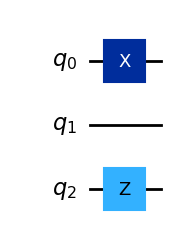


Circuit After reverse_bits() (Big-Endian Ordering):


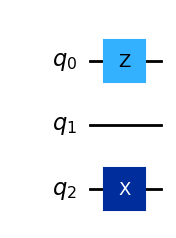

In [8]:
# Create a 3-qubit circuit to clearly show the reversal
qc = QuantumCircuit(3)

# Apply a distinctive gate to the first and last qubits
qc.x(0)
qc.z(2)

print("Original Circuit (Default Little-Endian Ordering):")
display(qc.draw('mpl'))

# Now, reverse the order of the bits
qc_reversed = qc.reverse_bits()

print("\nCircuit After reverse_bits() (Big-Endian Ordering):")
display(qc_reversed.draw('mpl'))

---

## 연습 문제 (Practice Questions)

**1. `QuantumCircuit` 객체의 어떤 속성이 포함된 명령 목록에 액세스할 수 있게 합니까?**

A) `circuit.instructions`

B) `circuit.data`

C) `circuit.ops`

D) `circuit.gates`

***정답:***
<Details>
<br/>
B) `circuit.data`
</Details>

---

**2. `qc.append()`와 `qc.compose()`의 차이점은 무엇입니까?**

A) `append`는 명령을 제자리에서 추가하는 반면, `compose`는 기본적으로 새 회로를 생성합니다.

B) `append`는 회로를 단일 불투명 명령으로 추가하는 반면, `compose`는 회로를 개별 게이트로 평탄화합니다.

C) 차이가 없으며, 서로 별칭(alias)입니다.

D) `compose`는 게이트에 사용되고, `append`는 측정에 사용됩니다.

***정답:***
<Details>
<br/>
B) `append`는 회로를 단일 불투명 명령으로 추가하는 반면, `compose`는 회로를 개별 게이트로 평탄화합니다.
</Details>

---

**3. 양자 회로의 깊은 복사(deep copy)를 생성하기 위해 어떤 메서드를 사용하시겠습니까?**

A) `qc.clone()`

B) `qc.duplicate()`

C) `qc.copy()`

D) `copy(qc)`

***정답:***
<Details>
<br/>
C) `qc.copy()`
</Details>